## Importando librerias necesarias y visualizacion de datos

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from fastapi import FastAPI
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  
import matplotlib as mpl
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import unicodedata

def normalizar_texto(texto):
    """Normaliza el texto removiendo acentos y convirtiendo a minúsculas."""
    if not isinstance(texto, str):
        return texto
    # Normalizar a forma NFD (descomponer caracteres)
    texto_normalizado = unicodedata.normalize('NFD', texto)
    # Remover caracteres de combinación (acentos)
    texto_sin_acentos = ''.join(c for c in texto_normalizado if unicodedata.category(c) != 'Mn')
    return texto_sin_acentos.lower()

df = pd.read_csv('dataset_peritacion_10000.csv', encoding='latin-1')

# Normalizar columnas categóricas para ignorar acentos
df["provincia"] = df["provincia"].apply(normalizar_texto)
df["perito"] = df["perito"].apply(normalizar_texto)
df["compania"] = df["compania"].apply(normalizar_texto)

df.head()


,compania,videoperitacion,fecha_entrada,perito,provincia,honorario_gabinete,honorario_perito,tasacion_origen,tiempo_resolucion_dias
0,Allianz,No,2024-09-08,Perito B,Sevilla,50,16,7470,5.6
1,AXA,No,2025-06-21,Perito D,Zaragoza,59,29,7803,6.2
2,Mutua,No,2024-11-11,Perito D,Málaga,53,31,1060,1.0
3,Mapfre,Si,2025-04-05,Perito C,Madrid,43,30,5590,5.4
4,Linea Directa,No,2025-03-10,Perito A,Málaga,45,42,5426,6.7


### Visualizacion de tipos de datos para saber si hay nulos y entender que tipos de datos son los que se van a trabajar

In [2]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   compania                10000 non-null  str    
 1   videoperitacion         10000 non-null  str    
 2   fecha_entrada           10000 non-null  str    
 3   perito                  10000 non-null  str    
 4   provincia               10000 non-null  str    
 5   honorario_gabinete      10000 non-null  int64  
 6   honorario_perito        10000 non-null  int64  
 7   tasacion_origen         10000 non-null  int64  
 8   tiempo_resolucion_dias  10000 non-null  float64
dtypes: float64(1), int64(3), str(5)
memory usage: 703.3 KB


,honorario_gabinete,honorario_perito,tasacion_origen,tiempo_resolucion_dias
count,10000.000000,10000.00000,10000.000000,10000.000000
mean,39.339700,31.93600,4098.628200,4.217390
std,11.440341,10.03719,2235.467836,1.440574
min,20.000000,15.00000,201.000000,1.000000
25%,29.000000,23.00000,2187.000000,3.200000
50%,39.000000,32.00000,4055.000000,4.200000
75%,49.000000,41.00000,6011.000000,5.200000
max,59.000000,49.00000,7998.000000,9.500000


In [3]:
df["fecha_entrada"] = pd.to_datetime(df["fecha_entrada"])
#combierte la columna "fecha_entrada" a formato datetime
df["mes"] = df["fecha_entrada"].dt.month
#Extrae el mes (1–12)
df["dia_semana"] = df["fecha_entrada"].dt.day_name()
#Extrae el día (Monday, Tuesday…)


### Visualizacion de relacion entre videoperitacion y honorarios de gabinete y perito

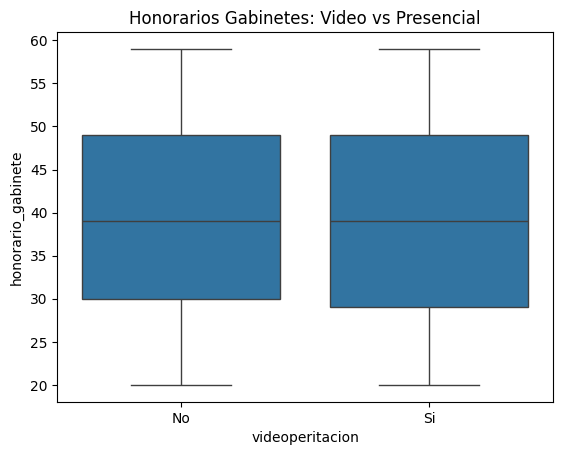

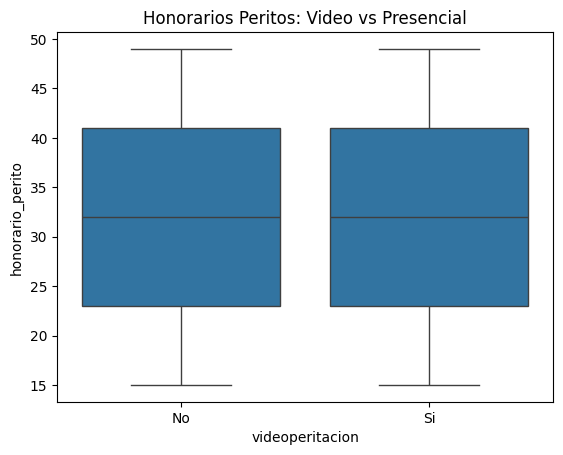

In [4]:
sns.boxplot(data=df, x="videoperitacion", y="honorario_gabinete")
plt.title("Honorarios Gabinetes: Video vs Presencial")
plt.show()
sns.boxplot(data=df, x="videoperitacion", y="honorario_perito")
plt.title("Honorarios Peritos: Video vs Presencial")
plt.show()

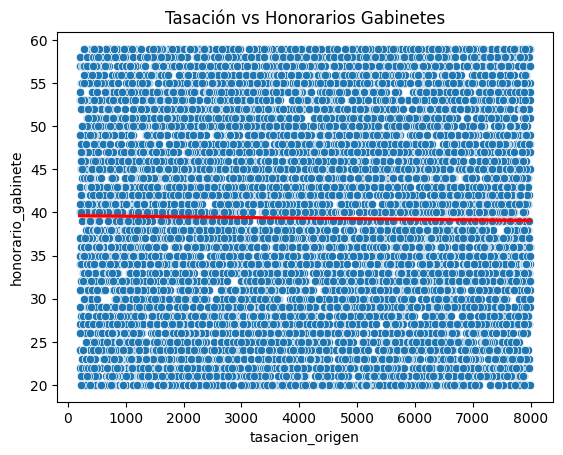

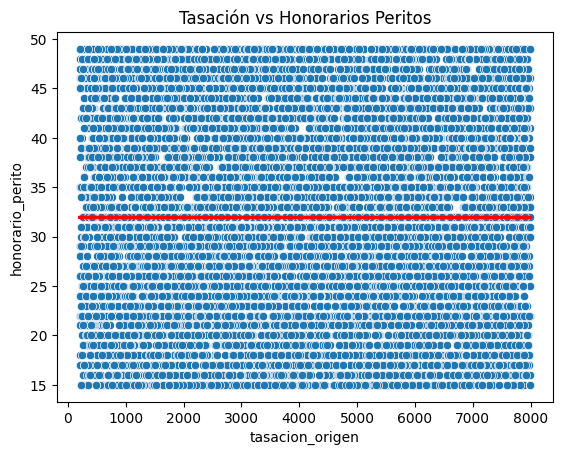

In [5]:
# Gabinetes
sns.scatterplot(data=df, x="tasacion_origen", y="honorario_gabinete")
sns.regplot(data=df, x="tasacion_origen", y="honorario_gabinete", scatter=False, color="red")
plt.title("Tasación vs Honorarios Gabinetes")
plt.show()
# Peritos
sns.scatterplot(data=df, x="tasacion_origen", y="honorario_perito")
sns.regplot(data=df, x="tasacion_origen", y="honorario_perito", scatter=False, color="red")
plt.title("Tasación vs Honorarios Peritos")
plt.show()

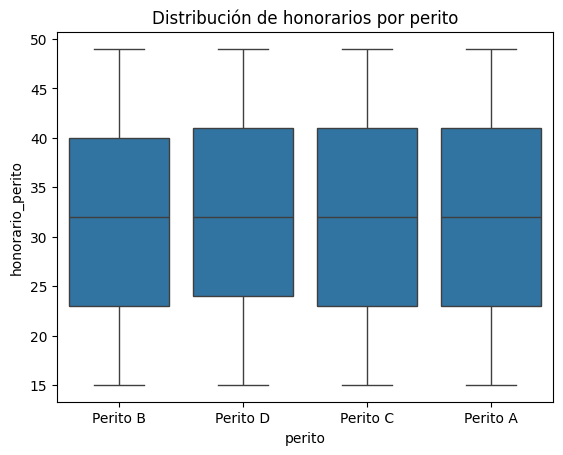

In [6]:
sns.boxplot(data=df, x="perito", y="honorario_perito")
plt.title("Distribución de honorarios por perito")
plt.show()

### comparacion de hororarios por provincia

In [7]:
ranking_gab = df.groupby("provincia")["honorario_gabinete"].mean().sort_values(ascending=False)
print(ranking_gab)
ranking_per = df.groupby("provincia")["honorario_perito"].mean().sort_values(ascending=False)
print(ranking_per)

provincia
Valencia     39.571429
Málaga       39.473469
Sevilla      39.325611
Zaragoza     39.234118
Madrid       39.233294
Barcelona    39.196841
Name: honorario_gabinete, dtype: float64
provincia
Barcelona    32.475091
Madrid       32.170644
Zaragoza     31.879412
Valencia     31.813325
Málaga       31.666472
Sevilla      31.611772
Name: honorario_perito, dtype: float64


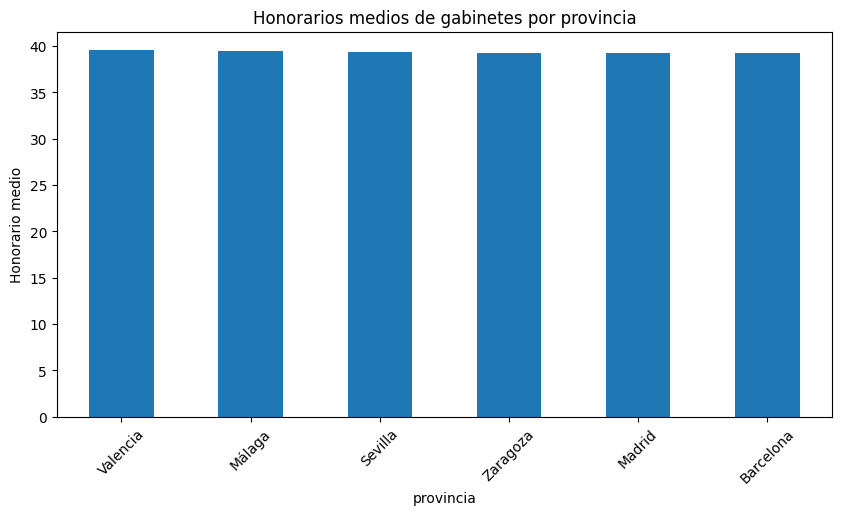

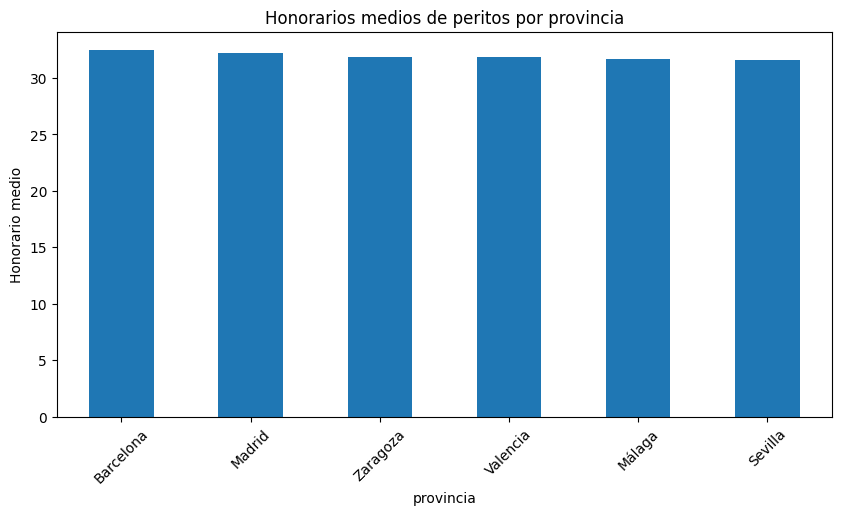

In [8]:

ranking_gab.plot(kind="bar", figsize=(10,5))
plt.title("Honorarios medios de gabinetes por provincia")
plt.ylabel("Honorario medio")
plt.xticks(rotation=45)
plt.show()

ranking_per.plot(kind="bar", figsize=(10,5))
plt.title("Honorarios medios de peritos por provincia")
plt.ylabel("Honorario medio")
plt.xticks(rotation=45)
plt.show()

### visualizacion facil de cuanto dias de resulocion suele haber

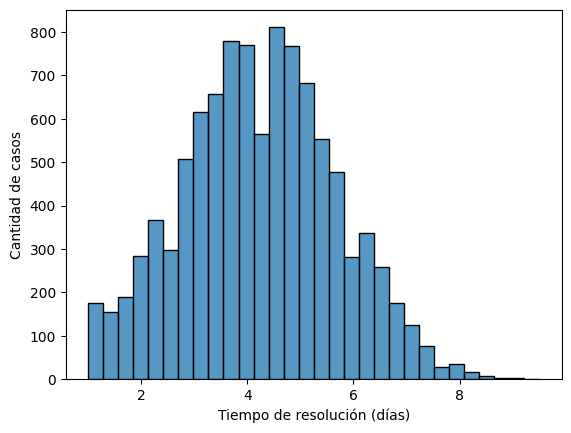

In [9]:
sns.histplot(df["tiempo_resolucion_dias"], bins=30)
plt.xlabel("Tiempo de resolución (días)")
plt.ylabel("Cantidad de casos")
plt.show()

<Axes: xlabel='compania', ylabel='tiempo_resolucion_dias'>

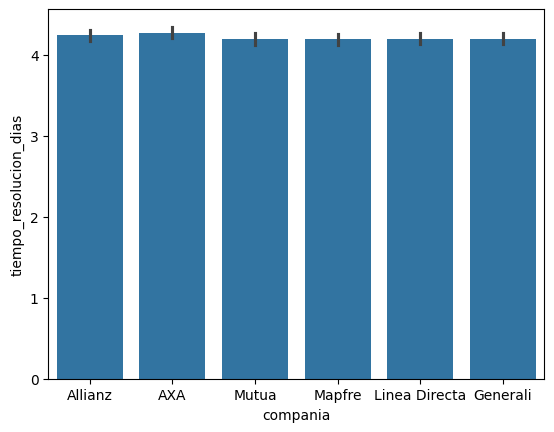

In [10]:
df.groupby("compania")["tiempo_resolucion_dias"].mean()
# Calcula el promedio por aseguradora
sns.barplot(x="compania", y="tiempo_resolucion_dias", data=df)
# Lo muestra en gráfico

#### diferencia de tiempo entre si se hace o no videoperitacion reduce el tiempo de finalizacion 

<Axes: xlabel='videoperitacion', ylabel='tiempo_resolucion_dias'>

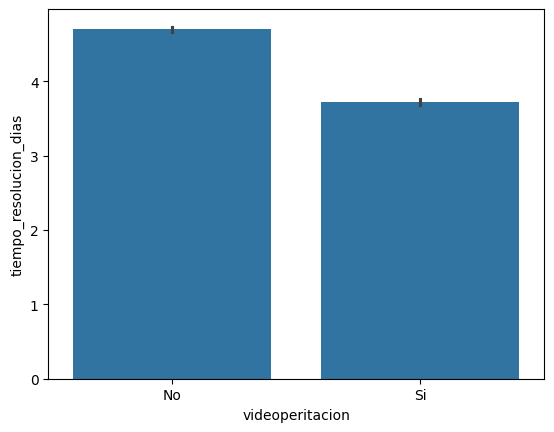

In [11]:
sns.barplot(x="videoperitacion", y="tiempo_resolucion_dias", data=df)

<Axes: xlabel='provincia', ylabel='tiempo_resolucion_dias'>

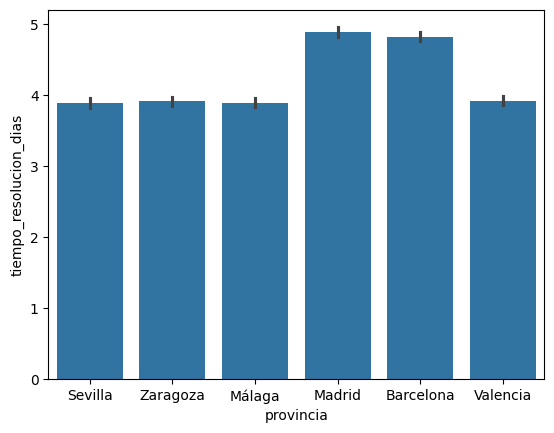

In [12]:
sns.barplot(x="provincia", y="tiempo_resolucion_dias", data=df)
#Ver qué zonas tardan más

<Axes: xlabel='perito', ylabel='tiempo_resolucion_dias'>

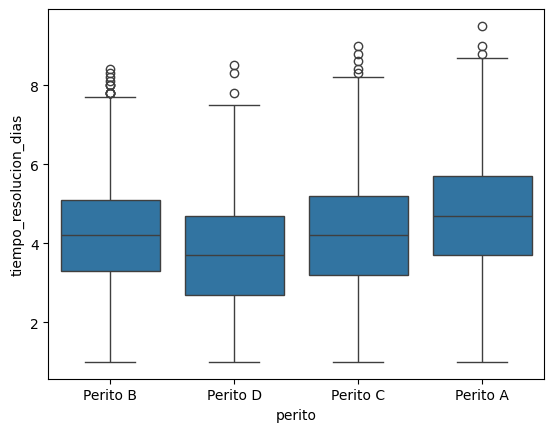

In [13]:
sns.boxplot(x="perito", y="tiempo_resolucion_dias", data=df)
#ver que perito tarda mas

<Axes: xlabel='tasacion_origen', ylabel='tiempo_resolucion_dias'>

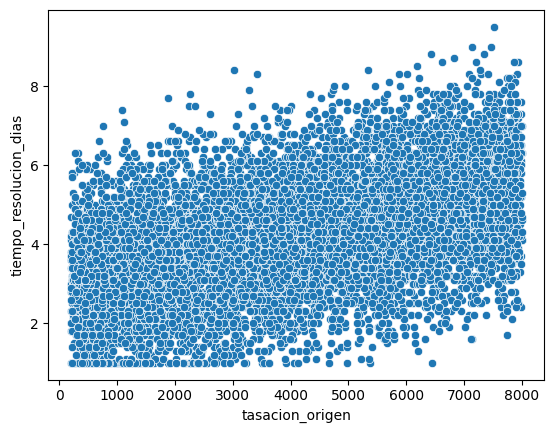

In [14]:
sns.scatterplot(x="tasacion_origen", y="tiempo_resolucion_dias", data=df)
#Ver si expedientes más caros tardan más

### canbiando variables categoricas a numericas para entrenamiento 

In [15]:
le_provincia = LabelEncoder()
df["provincia"] = le_provincia.fit_transform(df["provincia"])

le_perito = LabelEncoder()
df["perito"] = le_perito.fit_transform(df["perito"])

le_compania = LabelEncoder()
df["compania"] = le_compania.fit_transform(df["compania"])

le_video = LabelEncoder()
df["videoperitacion"] = le_video.fit_transform(df["videoperitacion"])

le_dia = LabelEncoder()
df["dia_semana"] = le_dia.fit_transform(df["dia_semana"])
# Codifica las variables categóricas a numéricas

### preparando datos para el modelo

In [16]:
X = df[[ 
    "provincia",
    "perito",
    "compania",
    "videoperitacion",
    "mes",
    "dia_semana",
    "honorario_gabinete",
    "honorario_perito",
    "tasacion_origen"
]]

y = df["tiempo_resolucion_dias"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(8000, 9)
(2000, 9)


### creando el modelo de random forest y entrenandolo

In [18]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
y_pred = model.predict(X_test)
print(y_pred[:10])
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

[6.174 6.411 3.766 2.58  5.121 3.479 4.423 4.728 4.091 5.854]
MAE: 0.8742140000000002
RMSE: 1.085155953768858


### para saber que variable inportan mas para el modelo

In [20]:
importancias = model.feature_importances_
variables = X.columns

df_importancia = pd.DataFrame({
    "variable": variables,
    "importancia": importancias
}).sort_values(by="importancia", ascending=False)

print(df_importancia)

             variable  importancia
8     tasacion_origen     0.368603
0           provincia     0.127289
3     videoperitacion     0.117521
6  honorario_gabinete     0.087423
7    honorario_perito     0.083683
1              perito     0.070969
4                 mes     0.057148
5          dia_semana     0.045893
2            compania     0.041472


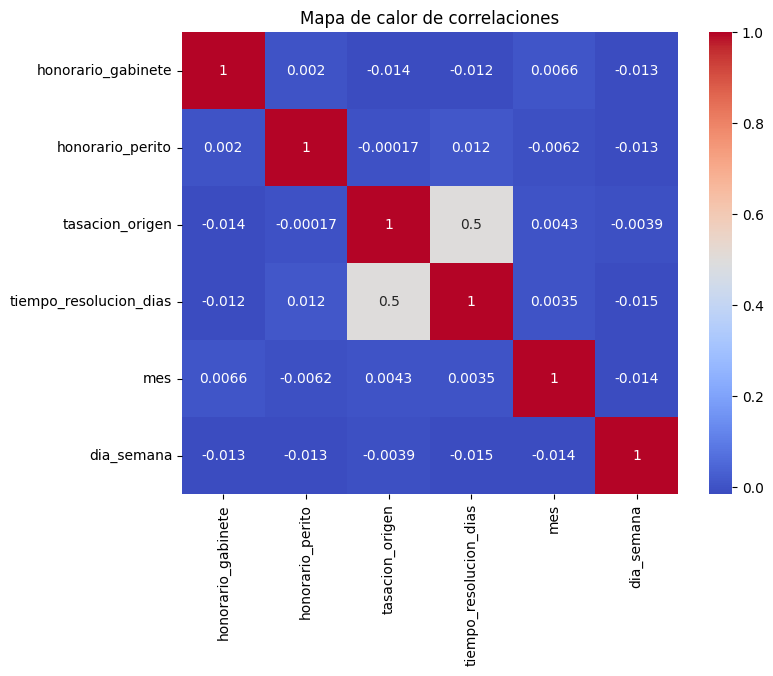

In [21]:
le = LabelEncoder()
df["dia_semana"] = le.fit_transform(df["dia_semana"])

columnas_corr = [
    "honorario_gabinete",
    "honorario_perito",
    "tasacion_origen",
    "tiempo_resolucion_dias",
    "mes",
    "dia_semana"
]

corr = df[columnas_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mapa de calor de correlaciones")
plt.show()

### creando variables de estacion del año

In [22]:
def obtener_estacion(mes):
    if mes in [12, 1, 2]:
        return "Invierno"
    elif mes in [3, 4, 5]:
        return "Primavera"
    elif mes in [6, 7, 8]:
        return "Verano"
    else:
        return "Otoño"

df["estacion"] = df["mes"].apply(obtener_estacion)

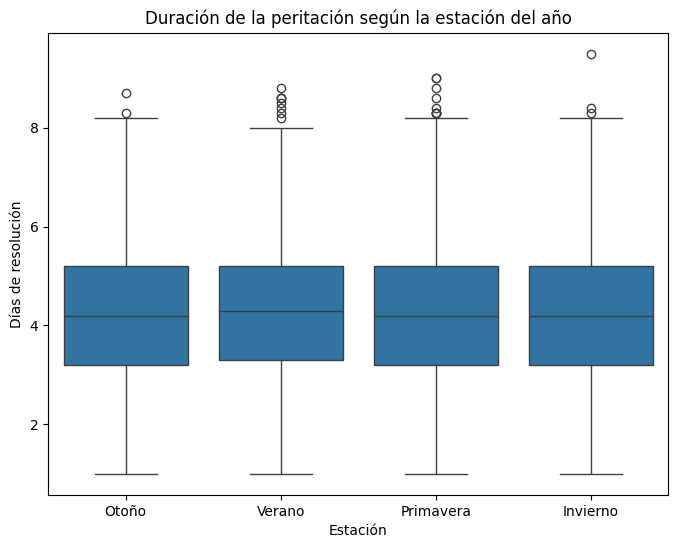

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(x="estacion", y="tiempo_resolucion_dias", data=df)

plt.title("Duración de la peritación según la estación del año")
plt.xlabel("Estación")
plt.ylabel("Días de resolución")

plt.show()

### Guardando el modelo

In [24]:
joblib.dump(model, "modelo.pkl")

['modelo.pkl']

In [25]:
preprocesador = {
    "provincia": le_provincia,
    "perito": le_perito,
    "compania": le_compania,
    "videoperitacion": le_video
}

joblib.dump(preprocesador, "preprocesador.pkl")

['preprocesador.pkl']

In [26]:
print(X.columns)

Index(['provincia', 'perito', 'compania', 'videoperitacion', 'mes',
       'dia_semana', 'honorario_gabinete', 'honorario_perito',
       'tasacion_origen'],
      dtype='str')
